### Denise Atherley
Week 3 - Part 2 Assigment Data Sets

## Analysis of the Davis Southern Women Dataset
The Davis Southern Women dataset is a classic example of a two-mode network. It contains two distinct types of nodes: Women and Social Events. Edges only exist between a woman and an event she attended.

To infer relationships between the women and the social events separately, I will have to project this two-mode graph into two unipartite (one-mode) graphs:

1. Women's Network: Two women are connected if they attended the same event.

2. Events Network: Two events are connected if the same woman attended both.

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from networkx.algorithms import bipartite

# 1. Load the built-in Davis Southern Women graph
G = nx.davis_southern_women_graph()

# Separate the nodes into two partitions
women = G.graph["top"]
events = G.graph["bottom"]

print(f"Total Women: {len(women)}")
print(f"Total Events: {len(events)}")
print(f"Is bipartite? {bipartite.is_bipartite(G)}")

Total Women: 18
Total Events: 14
Is bipartite? True


## 1. Inferring Relationships between the Women
To understand the social circles, I projected the network so that edges represent shared attendance at events. By calculating degree centrality (who has the most social connections) and betweenness centrality (who acts as a bridge between different social cliques), I was able to map the social hierarchy. Initially, I used the standard unweighted bipartite projection of the dataset and saw that my results displayed identical results for each woman. That prompted me to enhance the code to include a weighted projection and that is what I used for my analysis.

,Degree Centrality,Betweenness Centrality
Evelyn Jefferson,1.0,0.010122
Ruth DeSand,1.0,0.010122
Helen Lloyd,1.0,0.010122
Nora Fayette,1.0,0.010122
Sylvia Avondale,1.0,0.010122


,Weighted Degree (Strength),Weighted Betweenness Centrality
Theresa Anderson,57,0.261029
Nora Fayette,43,0.197304
Sylvia Avondale,46,0.063113
Evelyn Jefferson,50,0.031863
Brenda Rogers,46,0.011029
Laura Mandeville,45,0.002451


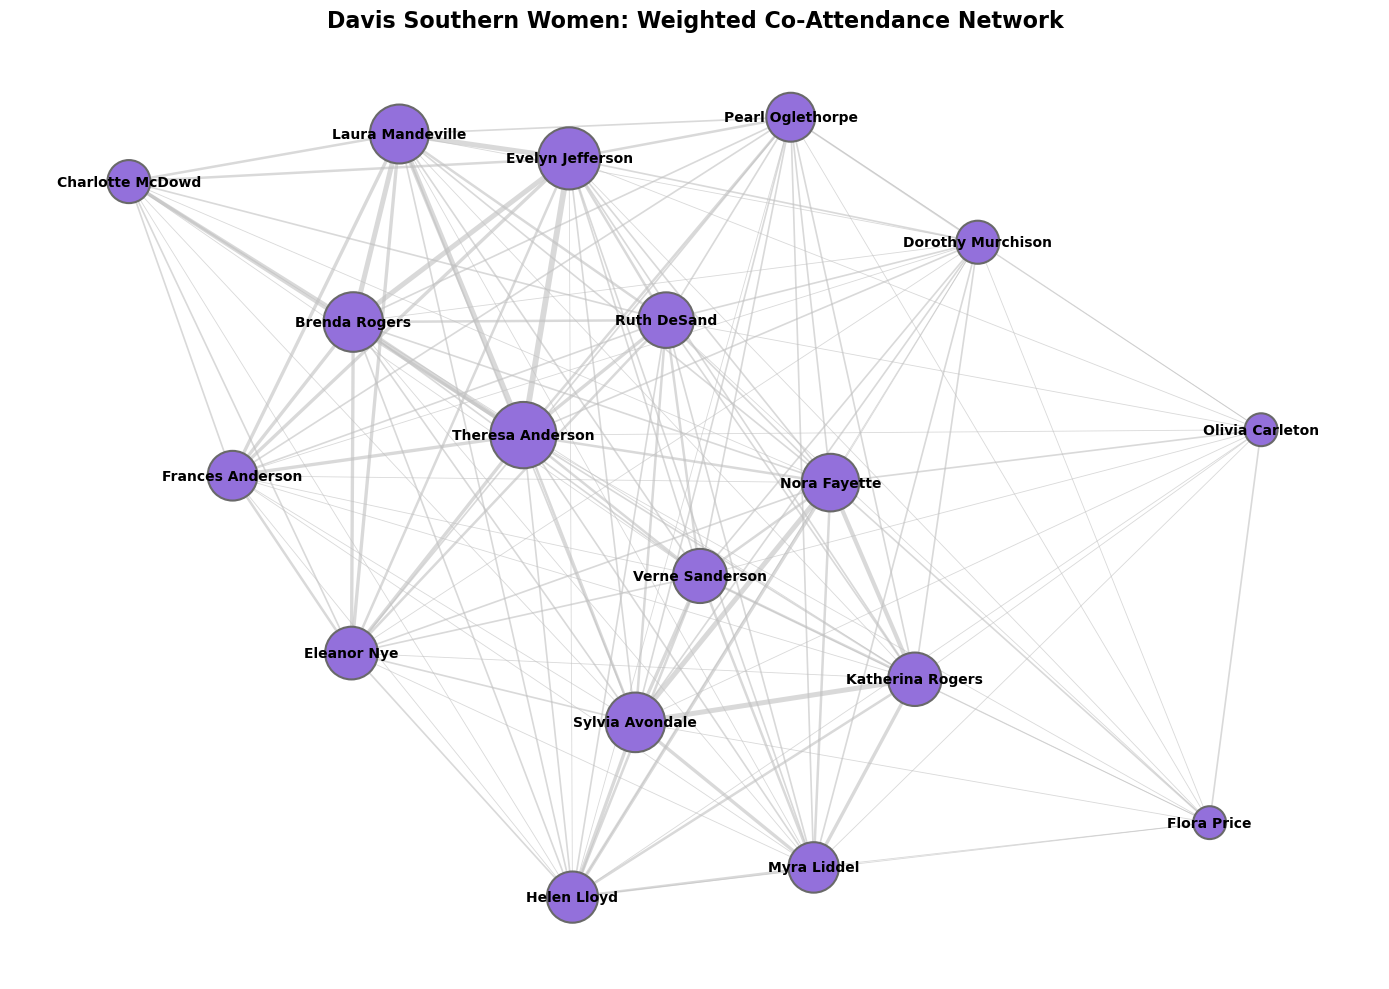

In [21]:
# Project the bipartite graph onto the women nodes
W = bipartite.projected_graph(G, women)

# Calculate centrality measures
deg_centrality_w = nx.degree_centrality(W)
bet_centrality_w = nx.betweenness_centrality(W)

# Combine into a DataFrame for analysis
women_df = pd.DataFrame({
    'Degree Centrality': deg_centrality_w,
    'Betweenness Centrality': bet_centrality_w
}).sort_values(by='Betweenness Centrality', ascending=False)

display(women_df.head(5))

# Create a weighted projected graph for the women
W_weighted = bipartite.weighted_projected_graph(G, women)

# Calculate Weighted Degree (often called Node Strength)
# This sums the weights (number of shared events) on all edges connected to a node
node_strength = dict(W_weighted.degree(weight='weight'))

# Calculate Weighted Betweenness Centrality
# Invert the weight into a 'distance' metric. 
# 4 shared events = distance of 0.25 (close). 1 shared event = distance of 1.0 (far).
for u, v, d in W_weighted.edges(data=True):
    d['distance'] = 1.0 / d['weight']

# Run the centrality algorithm using our new distance metric
bet_centrality_weighted = nx.betweenness_centrality(W_weighted, weight='distance')

# Combine into a DataFrame and compare
weighted_df = pd.DataFrame({
    'Weighted Degree (Strength)': node_strength,
    'Weighted Betweenness Centrality': bet_centrality_weighted
}).sort_values(by='Weighted Betweenness Centrality', ascending=False)

display(weighted_df.head(6))

# Plot the women's network
# Generate a layout that respects edge weights
# Stronger connections will pull nodes closer together physically
pos_weighted = nx.spring_layout(W_weighted, weight='weight', seed=42)

# Extract edge weights to determine line thickness
# We multiply by a scaling factor (e.g., 0.5) to keep the thickest lines manageable
edge_weights = [W_weighted[u][v]['weight'] for u, v in W_weighted.edges()]
edge_widths = [w * 0.6 for w in edge_weights] 

# Extract node strengths for node sizes
# Multiply by a scaling factor to make the nodes visible
node_sizes = [node_strength[n] * 40 for n in W_weighted.nodes()]

# Plot the graph in layers
plt.figure(figsize=(14, 10))

# Draw the edges first so they sit behind the nodes
nx.draw_networkx_edges(W_weighted, pos_weighted, 
                       width=edge_widths, 
                       edge_color='silver', 
                       alpha=0.6)

# Draw the nodes
nx.draw_networkx_nodes(W_weighted, pos_weighted, 
                       node_color='mediumpurple', 
                       node_size=node_sizes, 
                       edgecolors='dimgray',
                       linewidths=1.5)

# Draw the labels
nx.draw_networkx_labels(W_weighted, pos_weighted, 
                        font_size=10, 
                        font_weight='bold', 
                        font_color='black')

# Finalize the plot
plt.title("Davis Southern Women: Weighted Co-Attendance Network", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Community Detection: Splitting the Network
I also ran the Girvan-Newman algorithm to detect communities and identify if there are any distinct cliques.

Group 1 (17 women): ['Brenda Rogers', 'Dorothy Murchison', 'Eleanor Nye', 'Evelyn Jefferson', 'Flora Price', 'Frances Anderson', 'Helen Lloyd', 'Katherina Rogers', 'Laura Mandeville', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson', 'Verne Sanderson']

Group 2 (1 women): ['Charlotte McDowd']



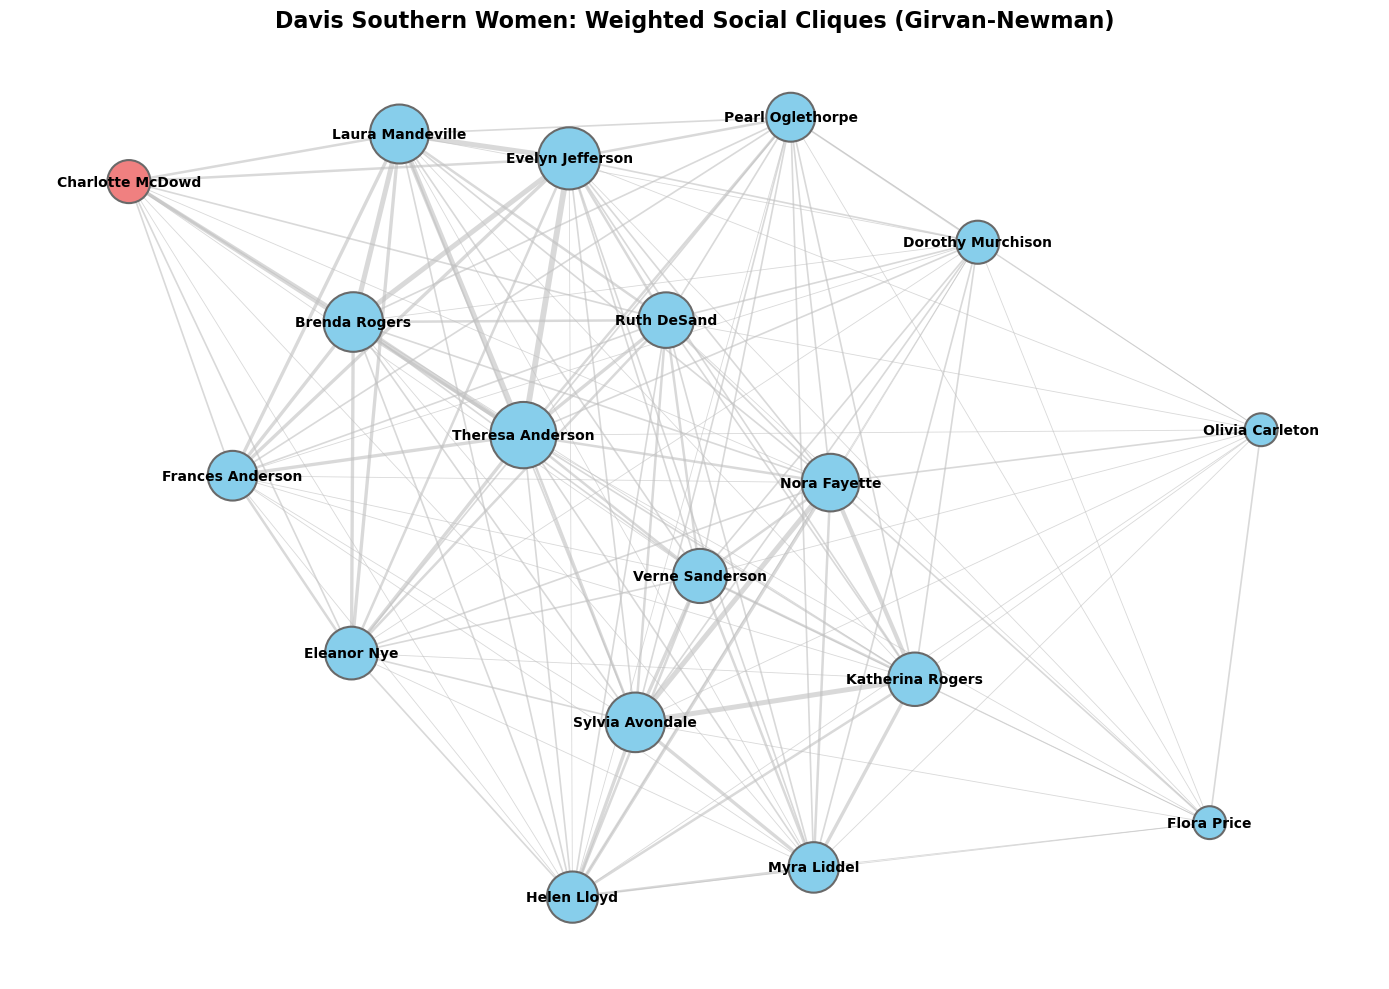

In [22]:
from networkx.algorithms.community import girvan_newman

# Define the custom function for weighted edge betweenness
# (Assuming W_weighted already has the 'distance' attribute: 1.0 / weight)
def highest_centrality_edge(G):
    edge_betweenness = nx.edge_betweenness_centrality(G, weight='distance')
    return max(edge_betweenness, key=edge_betweenness.get)

# Run the weighted Girvan-Newman community detection algorithm
weighted_communities_generator = girvan_newman(W_weighted, most_valuable_edge=highest_centrality_edge)

# Get the very first split (the top level of the hierarchy)
top_level_communities = next(weighted_communities_generator)
clique_1, clique_2 = top_level_communities

print(f"Group 1 ({len(clique_1)} women): {sorted(clique_1)}\n")
print(f"Group 2 ({len(clique_2)} women): {sorted(clique_2)}\n")

# Create a color map for the visualization based on these two communities
node_colors = []
for node in W_weighted.nodes():
    if node in clique_1:
        node_colors.append('skyblue')
    else:
        node_colors.append('lightcoral')

# Extract weights for visualization scaling
# Node sizes based on Weighted Degree (Node Strength)
node_sizes = [dict(W_weighted.degree(weight='weight'))[n] * 40 for n in W_weighted.nodes()]

# Edge widths based on the number of shared events
edge_widths = [W_weighted[u][v]['weight'] * 0.6 for u, v in W_weighted.edges()]

# Visualize the distinct cliques on the weighted projection
plt.figure(figsize=(14, 10))

# Use the weighted spring layout to pull tight-knit groups together
pos_weighted = nx.spring_layout(W_weighted, weight='weight', seed=42)

# Draw edges first
nx.draw_networkx_edges(W_weighted, pos_weighted, 
                       width=edge_widths, 
                       edge_color='silver', 
                       alpha=0.6)

# Draw nodes with community colors and strength-based sizes
nx.draw_networkx_nodes(W_weighted, pos_weighted, 
                       node_color=node_colors, 
                       node_size=node_sizes, 
                       edgecolors='dimgray',
                       linewidths=1.5)

# Draw labels
nx.draw_networkx_labels(W_weighted, pos_weighted, 
                        font_size=10, 
                        font_weight='bold')

plt.title("Davis Southern Women: Weighted Social Cliques (Girvan-Newman)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Analysis of the Women:
- Core vs. Peripheral Members: Women like Theresa Anderson, Evelyn Jefferson, and Nora Fayette score highest in both degree and betweenness centrality. They are the social glue of this network, attending the most events and socializing with the widest variety of people.

- Quality over Quantity: Look at Sylvia Avondale vs. Evelyn Jefferson. Evelyn has a higher total volume of interactions (Strength = 50 vs. Sylvia's 46). However, Sylvia has almost double Evelyn's Betweenness Centrality (0.063 vs. 0.031). This tells us that while Evelyn socializes a bit more overall, Sylvia's interactions are more strategically placed to bridge gaps between isolated members of the network.

- Distinct Social Circles: The algorithm shows that the network into two primary sub-groups. Group 1 (blue) is larger and centers heavily around Evelyn Jefferson and Theresa Anderson. Group 2 (red) centers around Charlotte McDowd.

- Bridging Ties: The women with high betweenness centrality (Theresa and Nora) act as the primary bridges between these two sub-groups. Without them, the cliques would be largely isolated from one another.


## 2. Inferring Relationships between the Social Events
Next, I projected the network onto the events. Here, an edge between Event A and Event B means that at least one woman attended both. The weight of that edge would represent how many women attended both.

,Weighted Degree (Strength),Weighted Betweenness Centrality
E8,59,0.435897
E9,46,0.294872
E1,19,0.000000
E2,20,0.000000
E3,32,0.000000
E4,23,0.000000


Event Group 1 (7 events): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E8']

Event Group 2 (7 events): ['E10', 'E11', 'E12', 'E13', 'E14', 'E7', 'E9']



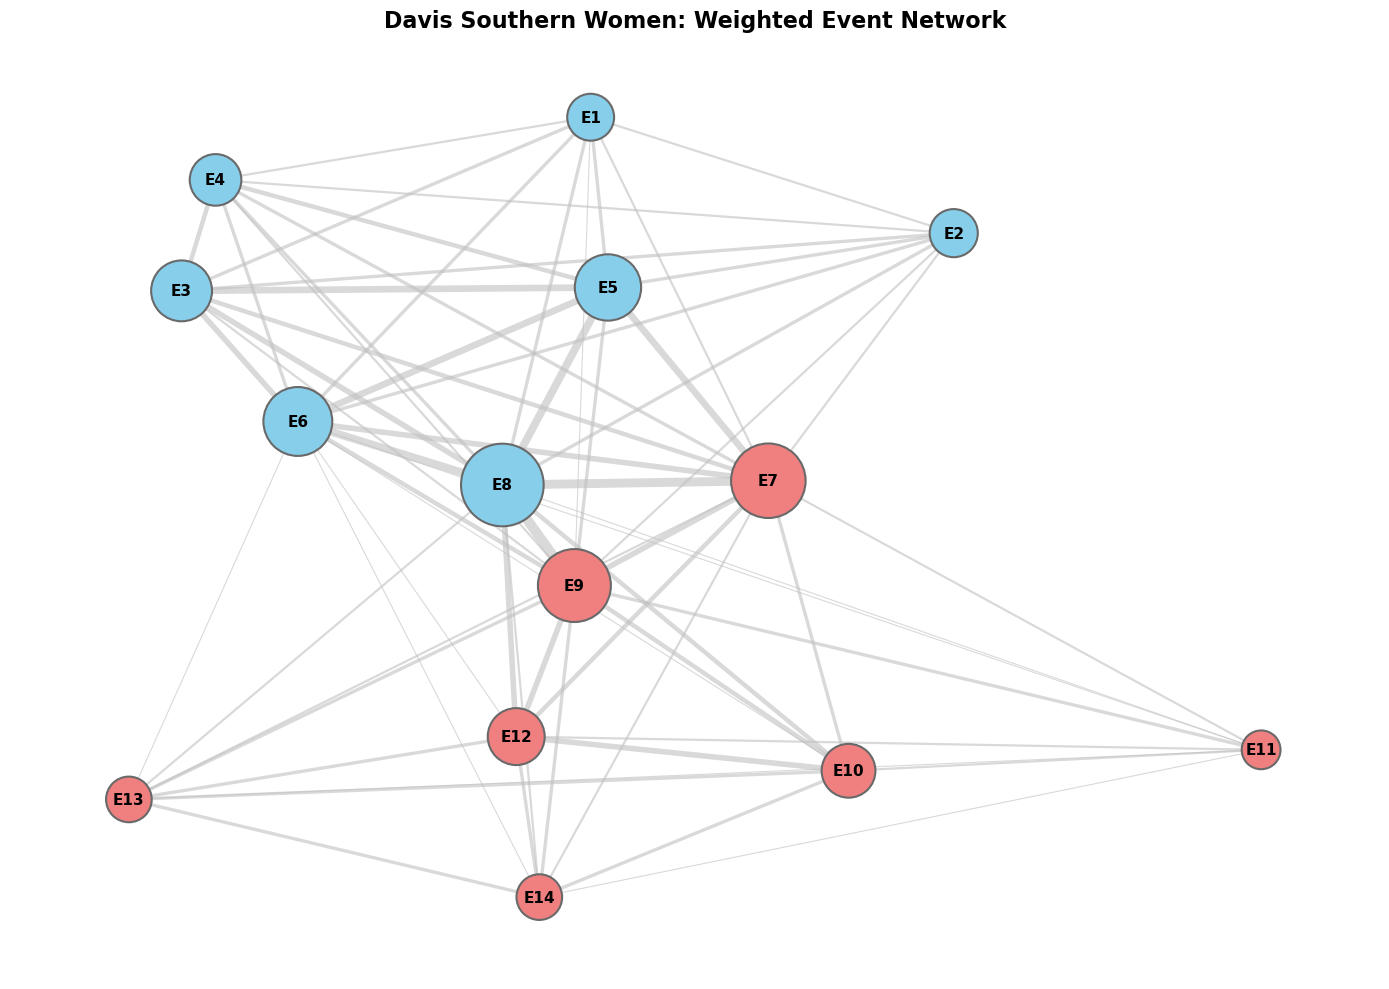

In [23]:
# Project the bipartite graph onto the event nodes
# Create a weighted projected graph for the events
E_weighted = bipartite.weighted_projected_graph(G, events)

# Calculate Weighted Degree (Node Strength)
# This sums the weights (number of overlapping women) on all edges connected to an event
event_strength = dict(E_weighted.degree(weight='weight'))

# Calculate Weighted Betweenness Centrality
# Invert the weight into a 'distance' metric (more shared women = shorter social distance)
for u, v, d in E_weighted.edges(data=True):
    d['distance'] = 1.0 / d['weight']

bet_centrality_e_weighted = nx.betweenness_centrality(E_weighted, weight='distance')

# Combine into a DataFrame
events_weighted_df = pd.DataFrame({
    'Weighted Degree (Strength)': event_strength,
    'Weighted Betweenness Centrality': bet_centrality_e_weighted
}).sort_values(by='Weighted Betweenness Centrality', ascending=False)

display(events_weighted_df.head(6))

# Run weighted Girvan-Newman on the events
event_communities_generator = girvan_newman(E_weighted, most_valuable_edge=highest_centrality_edge)

# Extract the top level of the hierarchy
event_clique_1, event_clique_2 = next(event_communities_generator)

print(f"Event Group 1 ({len(event_clique_1)} events): {sorted(event_clique_1)}\n")
print(f"Event Group 2 ({len(event_clique_2)} events): {sorted(event_clique_2)}\n")

# Create color map
event_colors = ['skyblue' if node in event_clique_1 else 'lightcoral' for node in E_weighted.nodes()]

# Extract scaling variables
event_sizes = [event_strength[n] * 60 for n in E_weighted.nodes()]
event_edge_widths = [E_weighted[u][v]['weight'] * 0.8 for u, v in E_weighted.edges()]

# Visualize
plt.figure(figsize=(14, 10))
pos_e_weighted = nx.spring_layout(E_weighted, weight='weight', seed=42)

nx.draw_networkx_edges(E_weighted, pos_e_weighted, width=event_edge_widths, edge_color='silver', alpha=0.6)
nx.draw_networkx_nodes(E_weighted, pos_e_weighted, node_color=event_colors, node_size=event_sizes, edgecolors='dimgray', linewidths=1.5)
nx.draw_networkx_labels(E_weighted, pos_e_weighted, font_size=11, font_weight='bold')

plt.title("Davis Southern Women: Weighted Event Network", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Analysis of the Events:
- Global Gatherings vs. Intimate Mixers: Events like E8 and E9 act as massive hubs. They have the highest centrality, meaning they drew women from across both of the distinct social cliques identified above. These were likely large, inclusive functions, like a major charity ball or community wide event.

- Exclusive/Niche Events: Events on the periphery of the network (with lower centrality, such as E1 or E14) were likely smaller, intimate gatherings hosted by or exclusively for one specific clique.

- Event Dependency: The high connectivity of the central events indicates that if you wanted to spread information to the entire network of 18 women, events E8 and E9 would be the most efficient venues to do so.